In [1]:
iter = 14
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/sep2012/v2_updatedweights/validate_fwd/iter' + str(iter) + '/'

In [2]:
import xarray as xr

profile_path = '/data/SO3/edavenport/tpose6/sep2012/run_ad_fixed_UVsigma/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'
ds_adcp = xr.open_dataset(profile_path)
profile_path = '/data/SO3/edavenport/tpose6/sep2012/run_ad_fixed_UVsigma/PROF_eq/TAO_WO_2012_CUR_v2_model.nc'
ds_cur = xr.open_dataset(profile_path)

In [3]:
ds_adcp

<xarray.Dataset> Size: 107MB
Dimensions:        (iPROF: 35228, iDEPTH: 62)
Dimensions without coordinates: iPROF, iDEPTH
Data variables:
    prof_YYYYMMDD  (iPROF) float64 282kB ...
    prof_HHMMSS    (iPROF) float64 282kB ...
    prof_lon       (iPROF) float64 282kB ...
    prof_lat       (iPROF) float64 282kB ...
    prof_depth     (iDEPTH) float64 496B ...
    prof_descr     (iPROF) |S30 1MB ...
    prof_U         (iPROF, iDEPTH) float64 17MB ...
    prof_Uweight   (iPROF, iDEPTH) float64 17MB ...
    prof_V         (iPROF, iDEPTH) float64 17MB ...
    prof_Vweight   (iPROF, iDEPTH) float64 17MB ...
    prof_Uestim    (iPROF, iDEPTH) float64 17MB ...
    prof_Vestim    (iPROF, iDEPTH) float64 17MB ...
Attributes:
    Format:   The contents of this MITprof file were processed \nusing the MI...
    date:     18-Apr-2026

In [4]:
import pandas as pd
# Combine date and time into a datetime array
dates = ds_adcp['prof_YYYYMMDD'].values.astype(int)
times = ds_adcp['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_adcp = ds_adcp.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
ds_adcp = ds_adcp.assign_coords(depth=('iDEPTH', ds_adcp['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
ds_adcp = ds_adcp.assign_coords(lat=('iPROF', ds_adcp['prof_lat'].values))
ds_adcp = ds_adcp.assign_coords(lon=('iPROF', ds_adcp['prof_lon'].values))
# ds_adcp.set_index(lat='lat', lon='lon')
# Combine date and time into a datetime array
dates = ds_cur['prof_YYYYMMDD'].values.astype(int)
times = ds_cur['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_cur = ds_cur.assign_coords(time=('iPROF', datetimes))
# ds_cur = ds_cur.swap_dims({'iPROF': 'time'})
ds_cur = ds_cur.assign_coords(depth=('iDEPTH', ds_cur['prof_depth'].values*-1))
# ds_cur = ds_cur.swap_dims({'iDEPTH': 'depth'})
ds_cur = ds_cur.assign_coords(lat=('iPROF', ds_cur['prof_lat'].values))
ds_cur = ds_cur.assign_coords(lon=('iPROF', ds_cur['prof_lon'].values))

In [5]:
ds_cur

<xarray.Dataset> Size: 23MB
Dimensions:        (iPROF: 26421, iDEPTH: 16)
Coordinates:
    time           (iPROF) datetime64[ns] 211kB 2011-12-31T01:00:00 ... 2012-...
    depth          (iDEPTH) float64 128B -10.0 -12.0 -15.0 ... -200.0 -202.0
    lat            (iPROF) float64 211kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon            (iPROF) float64 211kB 147.0 147.0 147.0 ... -170.0 -170.0
Dimensions without coordinates: iPROF, iDEPTH
Data variables:
    prof_YYYYMMDD  (iPROF) float64 211kB 2.011e+07 2.011e+07 ... 2.012e+07
    prof_HHMMSS    (iPROF) float64 211kB 1e+04 2e+04 3e+04 ... 2.2e+05 2.3e+05
    prof_lon       (iPROF) float64 211kB 147.0 147.0 147.0 ... -170.0 -170.0
    prof_lat       (iPROF) float64 211kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    prof_depth     (iDEPTH) float64 128B 10.0 12.0 15.0 ... 150.0 200.0 202.0
    prof_descr     (iPROF) |S30 793kB ...
    prof_U         (iPROF, iDEPTH) float64 3MB ...
    prof_Uweight   (iPROF, iDEPTH) float64 3MB ...
    prof_V         (iPROF, iDEPTH) float64 3MB ...
    prof_Vweight   (iPROF, iDEPTH) float64 3MB ...
    prof_Uestim    (iPROF, iDEPTH) float64 3MB ...
    prof_Vestim    (iPROF, iDEPTH) float64 3MB ...
Attributes:
    Format:   The contents of this MITprof file were processed \nusing the MI...
    date:     18-Apr-2026

<DatasetGroupBy, grouped over 1 grouper(s), 4 groups in total:
    'lon': UniqueGrouper('lon'), 4/4 groups with labels -170.0, -140.0, -110.0, 165.0>


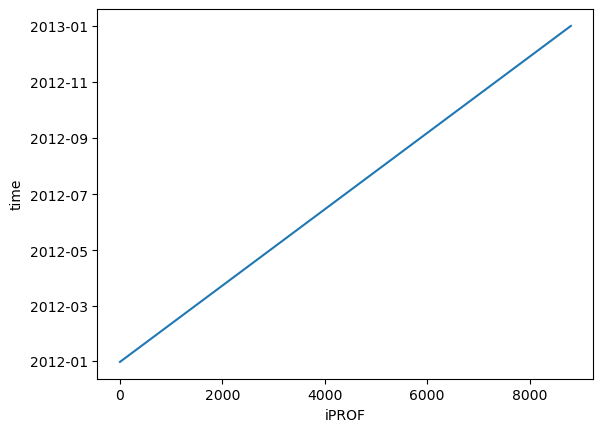

In [6]:
# group profiles by longitude (these are all equatorial TAO moorings)
adcp_by_lon = ds_adcp.groupby('lon')
# check that for a single longitude, time is monotonically increasing 
print(adcp_by_lon)
adcp_by_lon[-140.0].sortby('time').time.plot()

<DatasetGroupBy, grouped over 1 grouper(s), 3 groups in total:
    'lon': UniqueGrouper('lon'), 3/3 groups with labels -170.0, 147.0, 156.0>


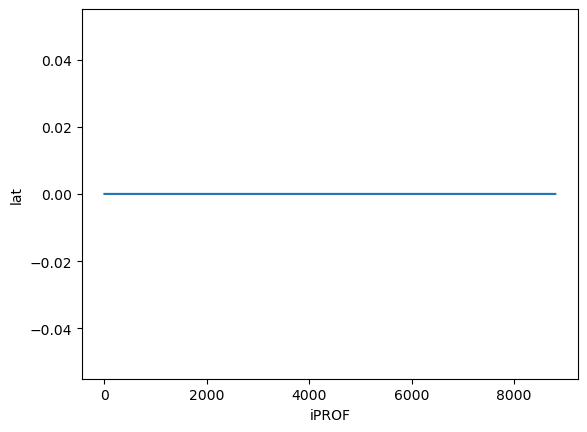

In [7]:
# group profiles by longitude (these are all equatorial TAO moorings)
cur_by_lon = ds_cur.groupby('lon')
# check that for a single longitude, time is monotonically increasing 
print(cur_by_lon)
cur_by_lon[-170.0].lat.plot()

In [8]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib.colors import TwoSlopeNorm
import cmocean.cm as cmo
warnings.filterwarnings("ignore")
plt.rcParams['font.size'] = 15


In [9]:
len(np.unique(adcp_by_lon[-170.0].prof_U.time))

8807

In [10]:
cur_by_lon[-170.0].sortby('time').prof_U

<xarray.DataArray 'prof_U' (iPROF: 8807, iDEPTH: 16)> Size: 1MB
[140912 values with dtype=float64]
Coordinates:
    time     (iPROF) datetime64[ns] 70kB 2011-12-31T01:00:00 ... 2012-12-31T2...
    depth    (iDEPTH) float64 128B -10.0 -12.0 -15.0 ... -150.0 -200.0 -202.0
    lat      (iPROF) float64 70kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    lon      (iPROF) float64 70kB -170.0 -170.0 -170.0 ... -170.0 -170.0 -170.0
Dimensions without coordinates: iPROF, iDEPTH
Attributes:
    long_name:  unknown
    units:      unknown

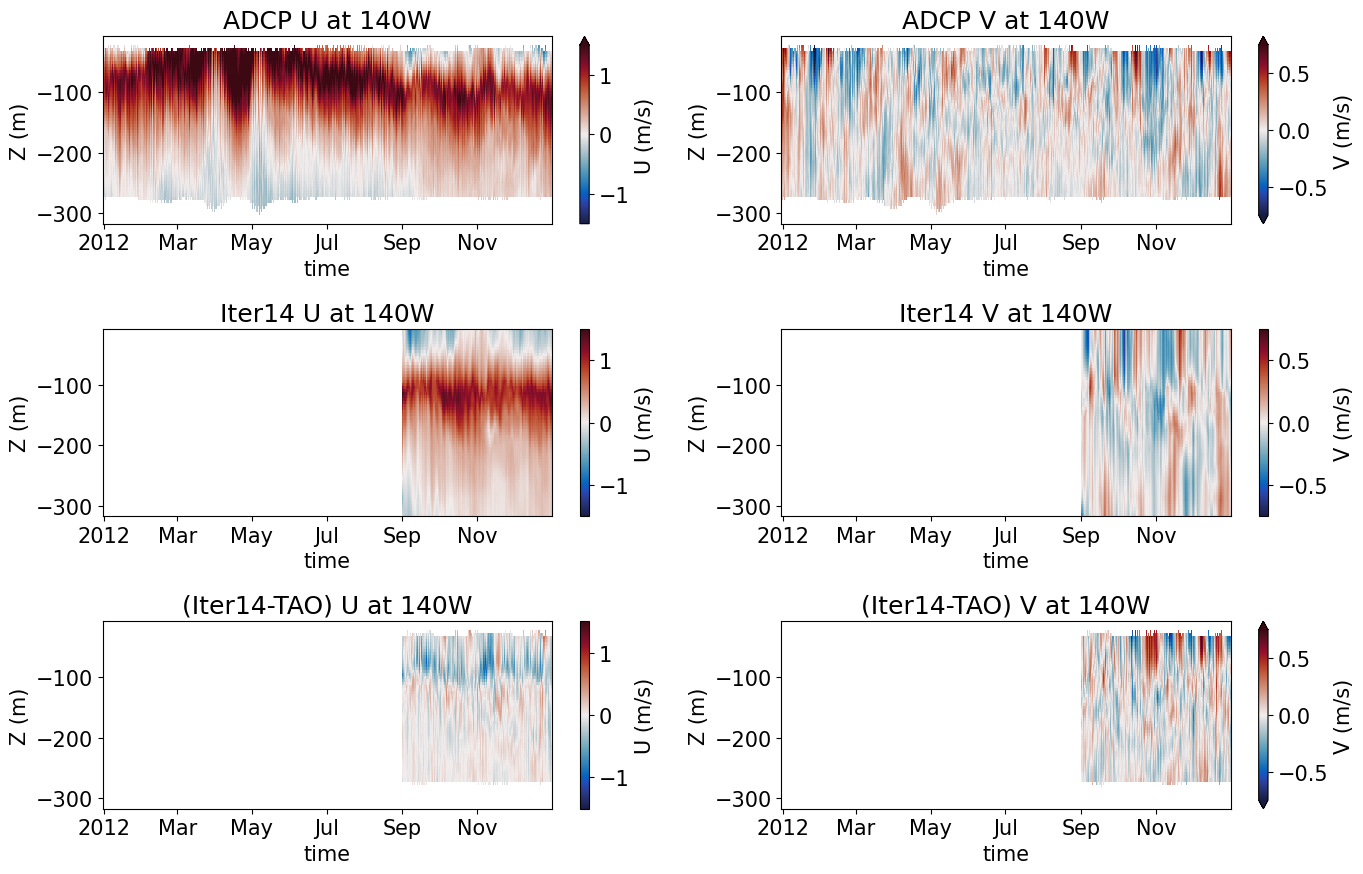

In [12]:
fig, ax = plt.subplots(figsize=(14,9),nrows=3, ncols=2)
adcp_by_lon[-140.0].sortby('time').prof_U.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[0,0].set_title('ADCP U at 140W')
ax[0,0].set_ylabel('Z (m)')
adcp_by_lon[-140.0].sortby('time').prof_Uestim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' U at 140W')
diff = adcp_by_lon[-140.0].sortby('time').prof_Uestim - adcp_by_lon[-140.0].sortby('time').prof_U
diff.plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,0].set_ylabel('Z (m)')

adcp_by_lon[-140.0].sortby('time').prof_V.plot(ax=ax[0,1],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[0,1].set_title('ADCP V at 140W')
ax[0,1].set_ylabel('Z (m)')
adcp_by_lon[-140.0].sortby('time').prof_Vestim.plot(ax=ax[1,1],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[1,1].set_ylabel('Z (m)')
ax[1,1].set_title('Iter'+ str(iter)+' V at 140W')
diff = adcp_by_lon[-140.0].sortby('time').prof_Vestim - adcp_by_lon[-140.0].sortby('time').prof_V
diff.T.plot(ax=ax[2,1],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,1].set_ylabel('Z (m)')

plt.tight_layout()
filename = foldername + 'adcp_profiles_vs_iter'+ str(iter)+'.png'
plt.savefig(filename)

In [13]:
def slice_by_time_keep_lon(group, start_time, end_time=None):
    """
    Slice a group (Dataset) by time without overwriting lon.
    
    group: xarray Dataset for a single lon
    start_time: np.datetime64 or string
    """
    # Boolean mask along the profile dimension (iPROF)
    mask = group.time >= np.datetime64(start_time)

    if end_time is not None:
        mask &= group.time <= np.datetime64(end_time)
    
    # Select the profiles, keep all coordinates intact
    return group.isel(iPROF=mask)

In [25]:
start_date = '2012-09-01'
end_date = '2012-12-31'

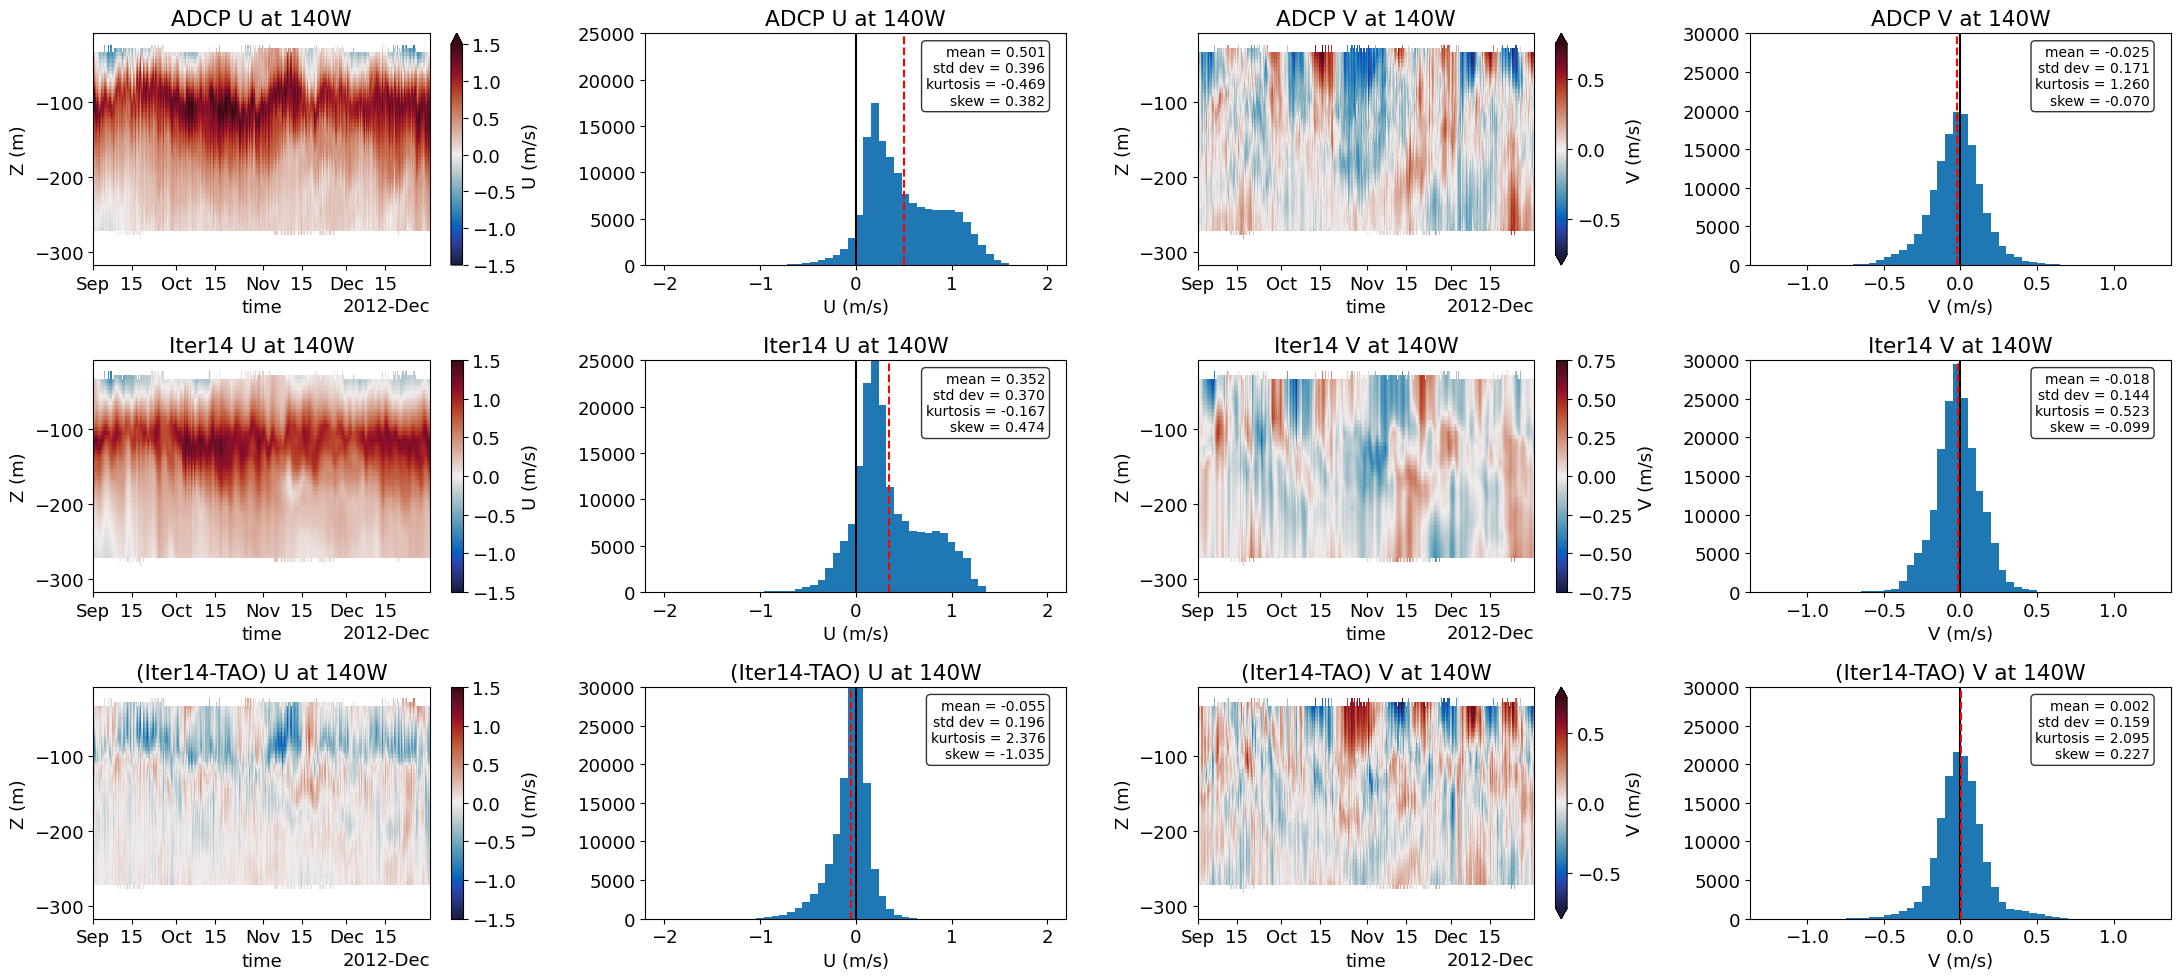

In [26]:
from scipy.stats import kurtosis, skew
vmin = -2.0
vmax = 2.0
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0].sortby('time'), start_date, end_date)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
adcp_by_lon_subset.prof_U.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[0,0].set_title('ADCP U at 140W')
ax[0,0].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Uestim.where(adcp_by_lon_subset.prof_U.notnull()).plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' U at 140W')
diff = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,0].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_U.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ADCP U at 140W')
ax[0,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_U.mean().values
std_u = adcp_by_lon_subset.prof_U.std().values
flat_nonan = adcp_by_lon_subset.prof_U.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Uestim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' U at 140W')
ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_Uestim.mean().values
std_u = adcp_by_lon_subset.prof_Uestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Uestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) U at 140W')
ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('U (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

adcp_by_lon_subset.prof_V.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[0,2].set_title('ADCP V at 140W')
ax[0,2].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Vestim.where(adcp_by_lon_subset.prof_V.notnull()).plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' V at 140W')
diff = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,2].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_V.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ADCP V at 140W')
ax[0,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_V.mean().values
std_u = adcp_by_lon_subset.prof_V.std().values
flat_nonan = adcp_by_lon_subset.prof_V.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Vestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' V at 140W')
ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_Vestim.mean().values
std_u = adcp_by_lon_subset.prof_Vestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Vestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) V at 140W')
ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('V (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_hist_140W.png'
plt.savefig(filename)

In [27]:
print(adcp_by_lon_subset.depth)

<xarray.DataArray 'depth' (iDEPTH: 62)> Size: 496B
array([ -10.,  -15.,  -20.,  -25.,  -30.,  -35.,  -40.,  -45.,  -50.,
        -55.,  -60.,  -65.,  -70.,  -75.,  -80.,  -85.,  -90.,  -95.,
       -100., -105., -110., -115., -120., -125., -130., -135., -140.,
       -145., -150., -155., -160., -165., -170., -175., -180., -185.,
       -190., -195., -200., -205., -210., -215., -220., -225., -230.,
       -235., -240., -245., -250., -255., -260., -265., -270., -275.,
       -280., -285., -290., -295., -300., -305., -310., -315.])
Coordinates:
    depth    (iDEPTH) float64 496B -10.0 -15.0 -20.0 ... -305.0 -310.0 -315.0
Dimensions without coordinates: iDEPTH


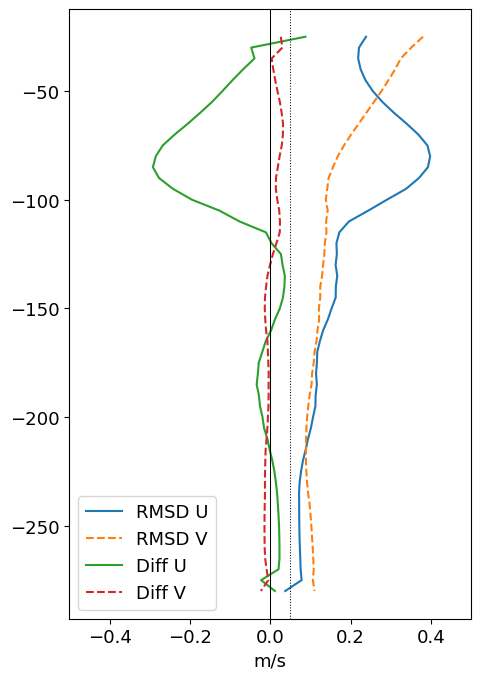

In [28]:
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0].sortby('time'),start_date, end_date)
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

rms_diffU = np.sqrt((diffU**2).mean(axis=0))
rms_diffV = np.sqrt((diffV**2).mean(axis=0))

fig, ax = plt.subplots(figsize=(5,7))
ax.plot(rms_diffU,adcp_by_lon_subset.depth,label='RMSD U')
ax.plot(rms_diffV,adcp_by_lon_subset.depth,label='RMSD V',linestyle='--')
ax.plot(diffU.mean(axis=0),adcp_by_lon_subset.depth,label='Diff U')
ax.plot(diffV.mean(axis=0),adcp_by_lon_subset.depth,label='Diff V',linestyle='--')
ax.axvline(0, color='k',linewidth=0.75)
ax.axvline(0.05, color='k', linestyle=':',linewidth=0.75)
ax.set_xlim(-0.5,0.5)
ax.set_xlabel('m/s')
ax.legend()
plt.tight_layout()

filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_RMSE_140W.png'
plt.savefig(filename)

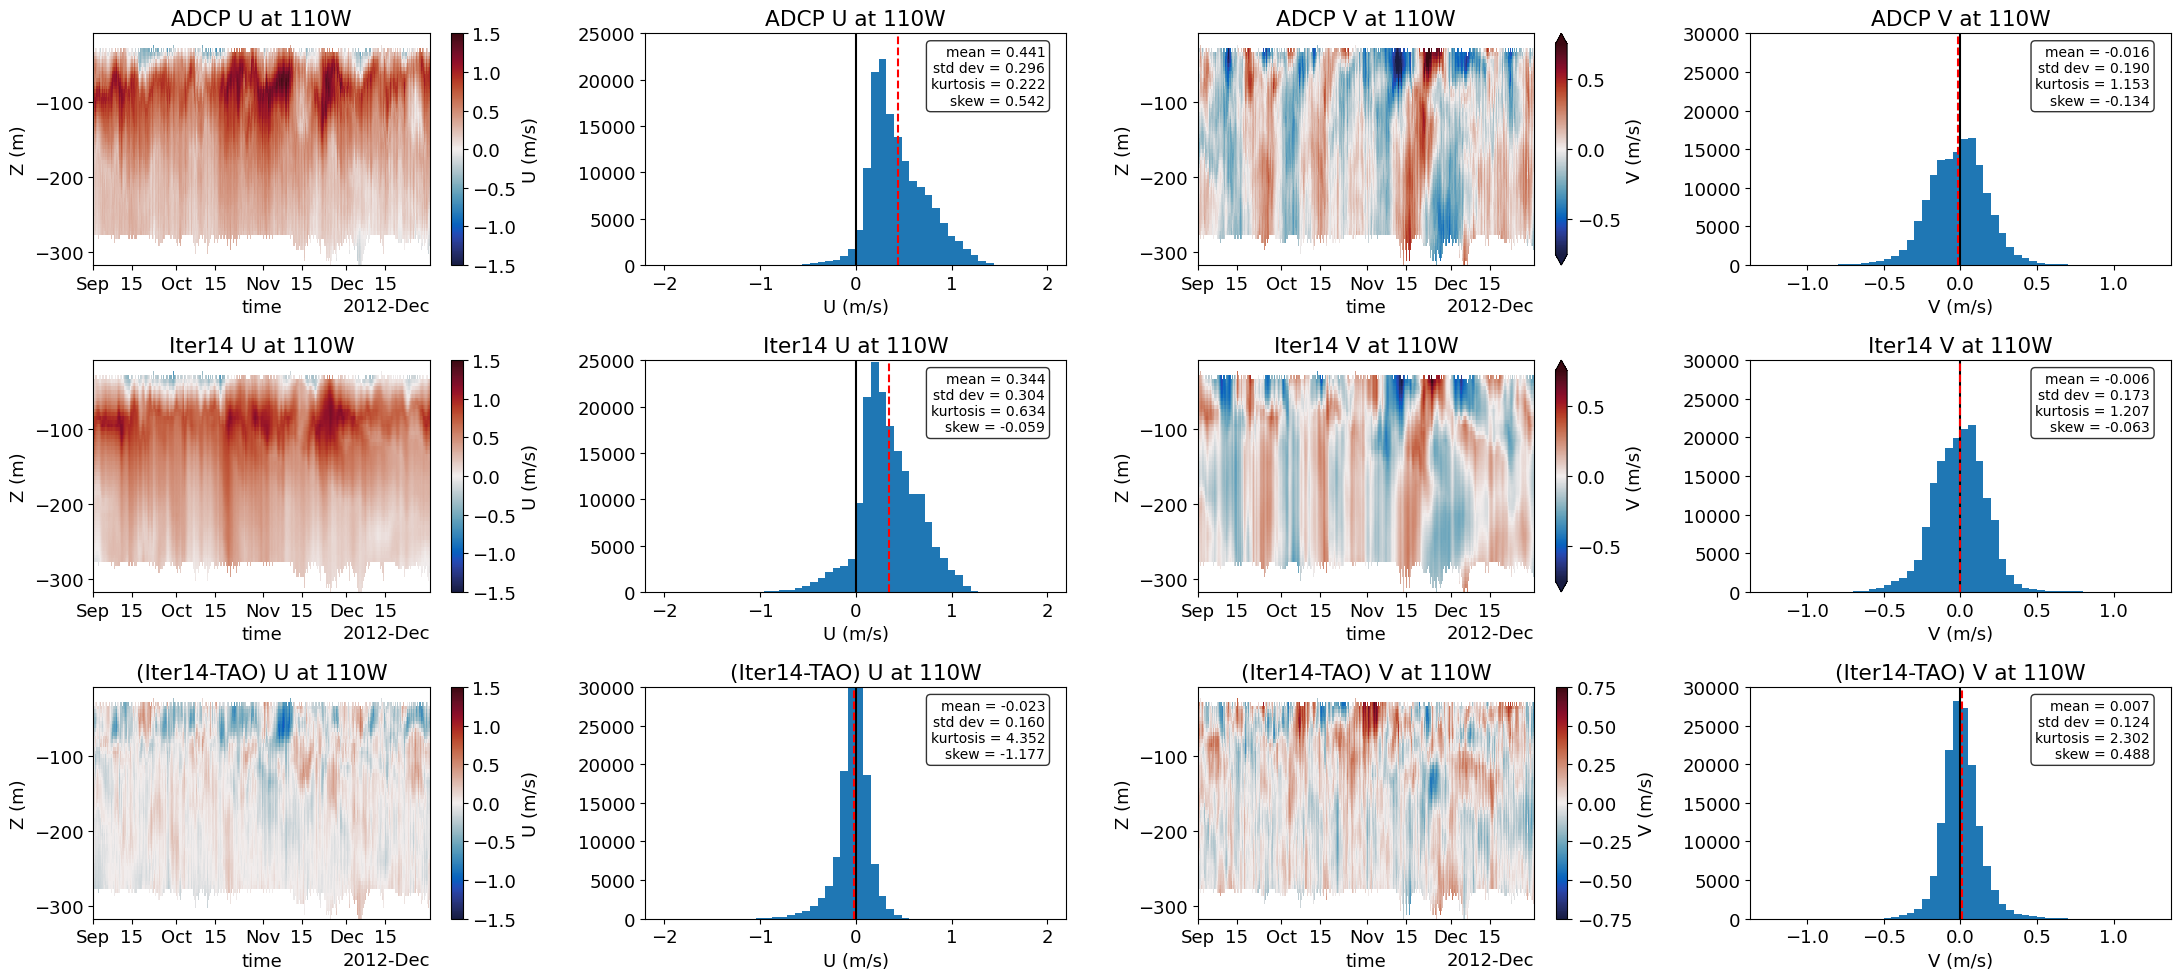

In [29]:
from scipy.stats import kurtosis, skew
vmin = -2.0
vmax = 2.0
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0].sortby('time'),start_date, end_date)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
adcp_by_lon_subset.prof_U.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[0,0].set_title('ADCP U at 110W')
ax[0,0].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Uestim.where(adcp_by_lon_subset.prof_U.notnull()).plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' U at 110W')
diff = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) U at 110W')
ax[2,0].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_U.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ADCP U at 110W')
ax[0,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_U.mean().values
std_u = adcp_by_lon_subset.prof_U.std().values
flat_nonan = adcp_by_lon_subset.prof_U.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Uestim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' U at 110W')
ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_Uestim.mean().values
std_u = adcp_by_lon_subset.prof_Uestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Uestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) U at 110W')
ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('U (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

adcp_by_lon_subset.prof_V.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[0,2].set_title('ADCP V at 110W')
ax[0,2].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Vestim.where(adcp_by_lon_subset.prof_V.notnull()).plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' V at 110W')
diff = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) V at 110W')
ax[2,2].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_V.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ADCP V at 110W')
ax[0,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_V.mean().values
std_u = adcp_by_lon_subset.prof_V.std().values
flat_nonan = adcp_by_lon_subset.prof_V.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Vestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' V at 110W')
ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_Vestim.mean().values
std_u = adcp_by_lon_subset.prof_Vestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Vestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) V at 110W')
ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('V (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_hist_110W.png'
plt.savefig(filename)

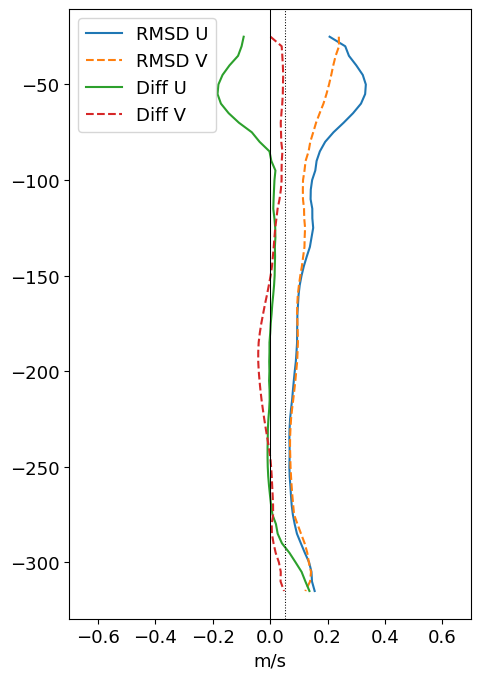

In [30]:
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0].sortby('time'),start_date, end_date)
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

rms_diffU = np.sqrt((diffU**2).mean(axis=0))
rms_diffV = np.sqrt((diffV**2).mean(axis=0))

fig, ax = plt.subplots(figsize=(5,7))
ax.plot(rms_diffU,adcp_by_lon_subset.depth,label='RMSD U')
ax.plot(rms_diffV,adcp_by_lon_subset.depth,label='RMSD V',linestyle='--')
ax.plot(diffU.mean(axis=0),adcp_by_lon_subset.depth,label='Diff U')
ax.plot(diffV.mean(axis=0),adcp_by_lon_subset.depth,label='Diff V',linestyle='--')
ax.axvline(0, color='k', linewidth=0.75)
ax.axvline(0.05, color='k', linestyle=':',linewidth=0.75)
ax.set_xlim(-0.7,0.7)
ax.set_xlabel('m/s')
ax.legend()
plt.tight_layout()

filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_RMSE_110W.png'
plt.savefig(filename)

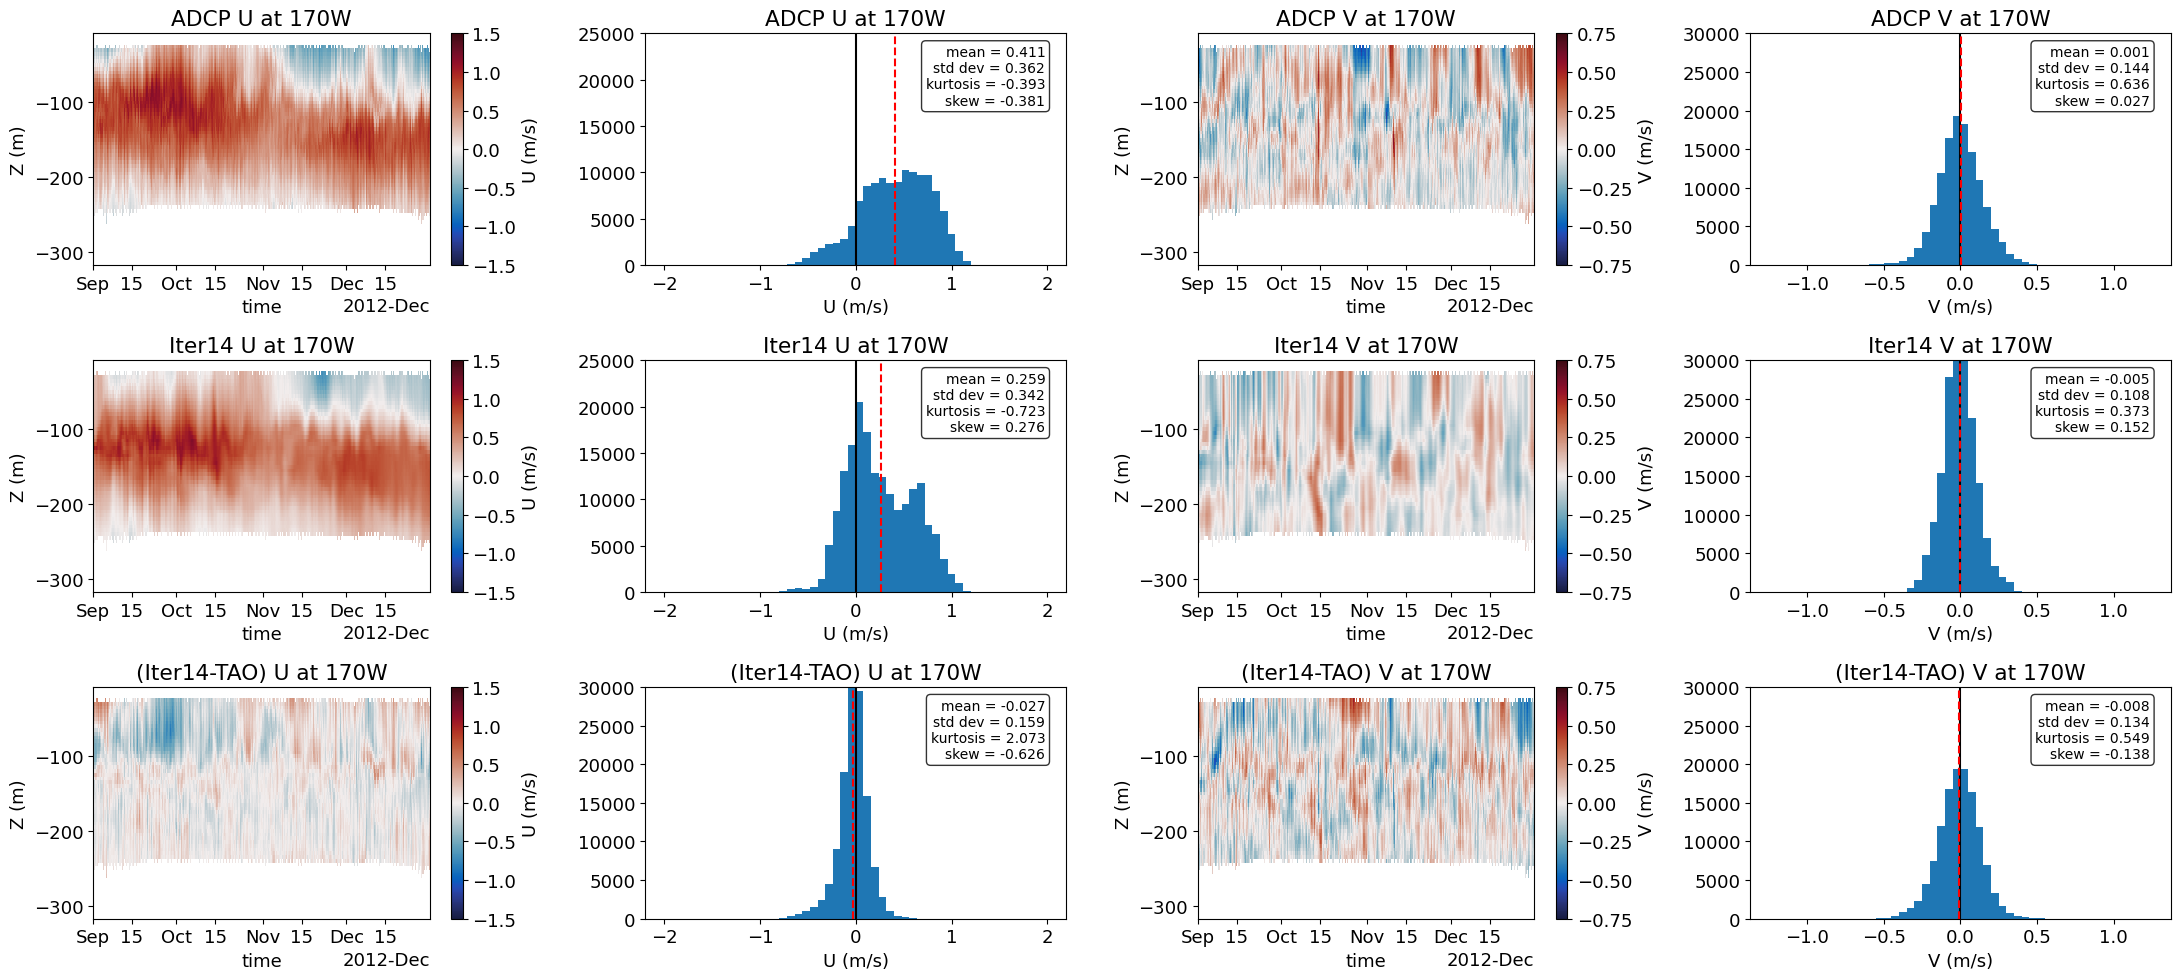

In [31]:
from scipy.stats import kurtosis, skew
vmin = -2.0
vmax = 2.0
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0].sortby('time'),start_date, end_date)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
adcp_by_lon_subset.prof_U.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[0,0].set_title('ADCP U at 170W')
ax[0,0].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Uestim.where(adcp_by_lon_subset.prof_U.notnull()).plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' U at 170W')
diff = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label': 'U (m/s)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) U at 170W')
ax[2,0].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_U.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ADCP U at 170W')
ax[0,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_U.mean().values
std_u = adcp_by_lon_subset.prof_U.std().values
flat_nonan = adcp_by_lon_subset.prof_U.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Uestim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' U at 170W')
ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('U (m/s)')
mean_u = adcp_by_lon_subset.prof_Uestim.mean().values
std_u = adcp_by_lon_subset.prof_Uestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Uestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) U at 170W')
ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('U (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

adcp_by_lon_subset.prof_V.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[0,2].set_title('ADCP V at 170W')
ax[0,2].set_ylabel('Z (m)')
adcp_by_lon_subset.prof_Vestim.where(adcp_by_lon_subset.prof_V.notnull()).plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' V at 170W')
diff = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label': 'V (m/s)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) V at 170W')
ax[2,2].set_ylabel('Z (m)')


adcp_by_lon_subset.prof_V.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ADCP V at 170W')
ax[0,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_V.mean().values
std_u = adcp_by_lon_subset.prof_V.std().values
flat_nonan = adcp_by_lon_subset.prof_V.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

adcp_by_lon_subset.prof_Vestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' V at 170W')
ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('V (m/s)')
mean_u = adcp_by_lon_subset.prof_Vestim.mean().values
std_u = adcp_by_lon_subset.prof_Vestim.std().values
flat_nonan = adcp_by_lon_subset.prof_Vestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) V at 170W')
ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('V (m/s)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_hist_170W.png'
plt.savefig(filename)

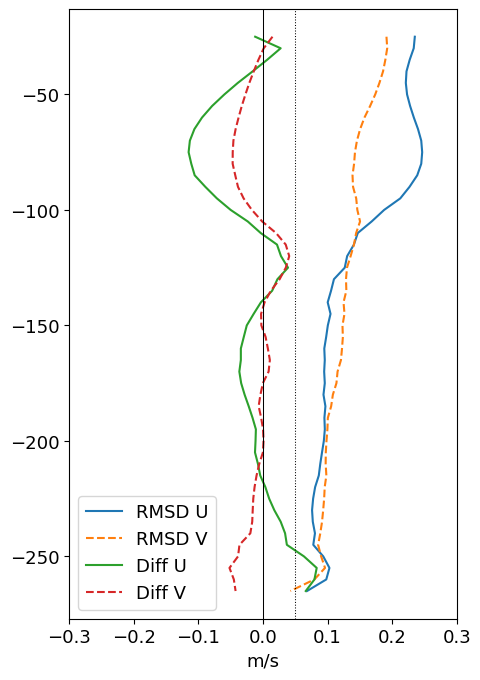

In [32]:
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0].sortby('time'),start_date, end_date)
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

rms_diffU = np.sqrt((diffU**2).mean(axis=0))
rms_diffV = np.sqrt((diffV**2).mean(axis=0))

fig, ax = plt.subplots(figsize=(5,7))
ax.plot(rms_diffU,adcp_by_lon_subset.depth,label='RMSD U')
ax.plot(rms_diffV,adcp_by_lon_subset.depth,label='RMSD V',linestyle='--')
ax.plot(diffU.mean(axis=0),adcp_by_lon_subset.depth,label='Diff U')
ax.plot(diffV.mean(axis=0),adcp_by_lon_subset.depth,label='Diff V',linestyle='--')
ax.axvline(0, color='k', linewidth=0.75)
ax.axvline(0.05, color='k', linestyle=':',linewidth=0.75)
ax.set_xlim(-0.3,0.3)
ax.set_xlabel('m/s')
ax.legend()
plt.tight_layout()

filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_RMSE_170W.png'
plt.savefig(filename)

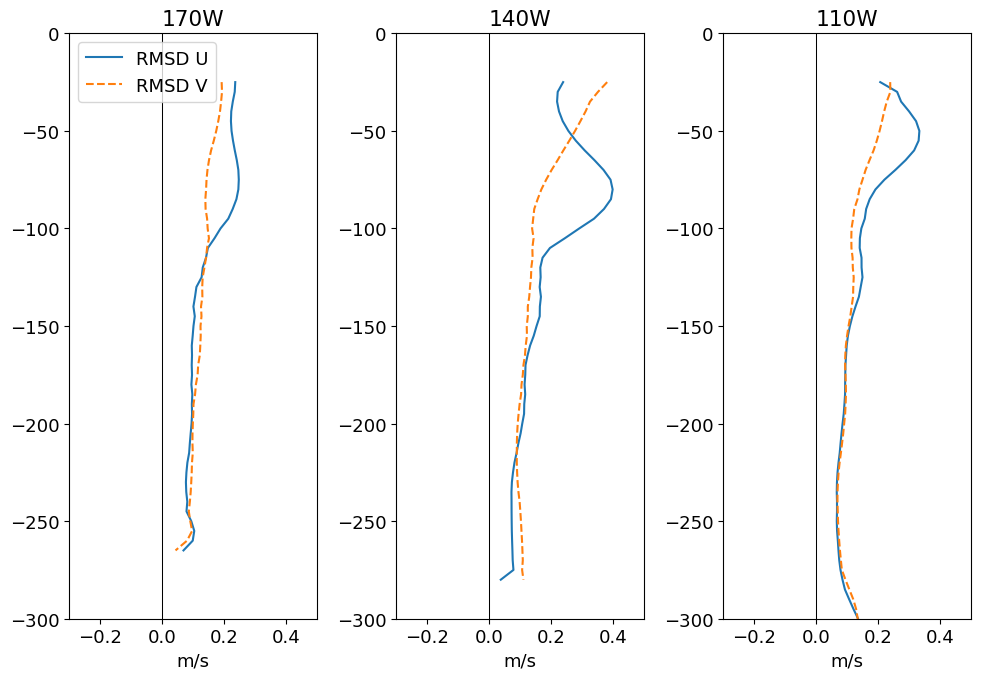

In [33]:
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0].sortby('time'),start_date, end_date)
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

rms_diffU = np.sqrt((diffU**2).mean(axis=0))
rms_diffV = np.sqrt((diffV**2).mean(axis=0))

plt.rcParams['font.size'] = 13

fig, ax = plt.subplots(figsize=(10,7),ncols=3)
ax[0].plot(rms_diffU,adcp_by_lon_subset.depth,label='RMSD U')
ax[0].plot(rms_diffV,adcp_by_lon_subset.depth,label='RMSD V',linestyle='--')
ax[0].axvline(0, color='k', linewidth=0.75)
ax[0].set_xlim(-0.3,0.5)
ax[0].set_xlabel('m/s')
ax[0].legend()
ax[0].set_title('170W')
ax[0].set_ylim(-300,0)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0].sortby('time'), start_date, end_date)
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

rms_diffU = np.sqrt((diffU**2).mean(axis=0))
rms_diffV = np.sqrt((diffV**2).mean(axis=0))

ax[1].plot(rms_diffU,adcp_by_lon_subset.depth,label='RMSD U')
ax[1].plot(rms_diffV,adcp_by_lon_subset.depth,label='RMSD V',linestyle='--')
ax[1].axvline(0, color='k', linewidth=0.75)
ax[1].set_xlim(-0.3,0.5)
ax[1].set_xlabel('m/s')
ax[1].set_title('140W')
ax[1].set_ylim(-300,0)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0].sortby('time'),start_date, end_date)
diffU = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diffV = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

rms_diffU = np.sqrt((diffU**2).mean(axis=0))
rms_diffV = np.sqrt((diffV**2).mean(axis=0))

ax[2].plot(rms_diffU,adcp_by_lon_subset.depth,label='RMSD U')
ax[2].plot(rms_diffV,adcp_by_lon_subset.depth,label='RMSD V',linestyle='--')
ax[2].axvline(0, color='k', linewidth=0.75)
ax[2].set_xlim(-0.3,0.5)
ax[2].set_xlabel('m/s')
ax[2].set_title('110W')
ax[2].set_ylim(-300,0)

plt.tight_layout()

filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_RMSE.png'
plt.savefig(filename)

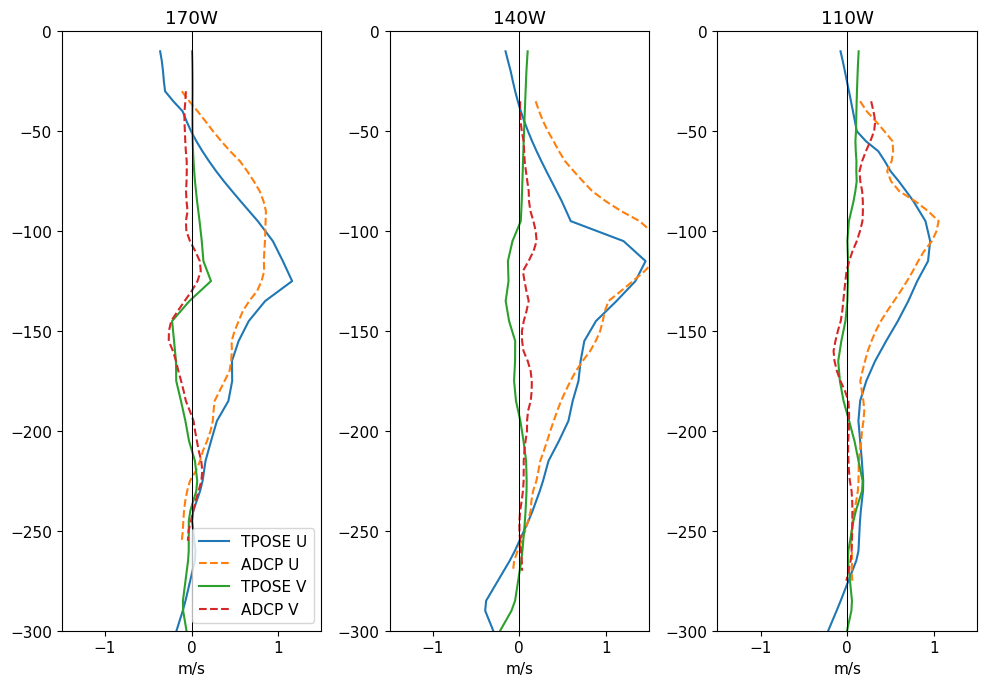

In [34]:
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0].sortby('time'),start_date, end_date)

plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(10,7),ncols=3)
ax[0].plot(adcp_by_lon_subset.isel(iPROF=1).prof_Uestim,adcp_by_lon_subset.depth,label='TPOSE U')
ax[0].plot(adcp_by_lon_subset.isel(iPROF=1).prof_U,adcp_by_lon_subset.depth,label='ADCP U',linestyle='--')
ax[0].plot(adcp_by_lon_subset.isel(iPROF=1).prof_Vestim,adcp_by_lon_subset.depth,label='TPOSE V')
ax[0].plot(adcp_by_lon_subset.isel(iPROF=1).prof_V,adcp_by_lon_subset.depth,label='ADCP V',linestyle='--')
# ax[0].plot(uncertainty,adcp_by_lon_subset.depth,label='Data Std Dev',linestyle=':')
ax[0].axvline(0, color='k', linewidth=0.75)
ax[0].set_xlim(-1.5,1.5)
ax[0].set_xlabel('m/s')
ax[0].legend()
ax[0].set_title('170W')
ax[0].set_ylim(-300,0)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0].sortby('time'),start_date, end_date)

ax[1].plot(adcp_by_lon_subset.isel(iPROF=1).prof_Uestim,adcp_by_lon_subset.depth,label='TPOSE U')
ax[1].plot(adcp_by_lon_subset.isel(iPROF=1).prof_U,adcp_by_lon_subset.depth,label='ADCP U',linestyle='--')
ax[1].plot(adcp_by_lon_subset.isel(iPROF=1).prof_Vestim,adcp_by_lon_subset.depth,label='TPOSE V')
ax[1].plot(adcp_by_lon_subset.isel(iPROF=1).prof_V,adcp_by_lon_subset.depth,label='ADCP V',linestyle='--')
# ax[1].plot(uncertainty,adcp_by_lon_subset.depth,label='Data Std Dev',linestyle=':')
ax[1].axvline(0, color='k', linewidth=0.75)
ax[1].set_xlim(-1.5,1.5)
ax[1].set_xlabel('m/s')
ax[1].set_title('140W')
ax[1].set_ylim(-300,0)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0].sortby('time'),start_date, end_date)

ax[2].plot(adcp_by_lon_subset.isel(iPROF=1).prof_Uestim,adcp_by_lon_subset.depth,label='TPOSE U')
ax[2].plot(adcp_by_lon_subset.isel(iPROF=1).prof_U,adcp_by_lon_subset.depth,label='ADCP U',linestyle='--')
ax[2].plot(adcp_by_lon_subset.isel(iPROF=1).prof_Vestim,adcp_by_lon_subset.depth,label='TPOSE V')
ax[2].plot(adcp_by_lon_subset.isel(iPROF=1).prof_V,adcp_by_lon_subset.depth,label='ADCP V',linestyle='--')
# ax[2].plot(uncertainty,adcp_by_lon_subset.depth,label='Data Std Dev',linestyle=' :')
ax[2].axvline(0, color='k', linewidth=0.75)
ax[2].set_xlim(-1.5,1.5)
ax[2].set_xlabel('m/s')
ax[2].set_title('110W')
ax[2].set_ylim(-300,0)

plt.tight_layout()

filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_RMSE_timestep0.png'
plt.savefig(filename)

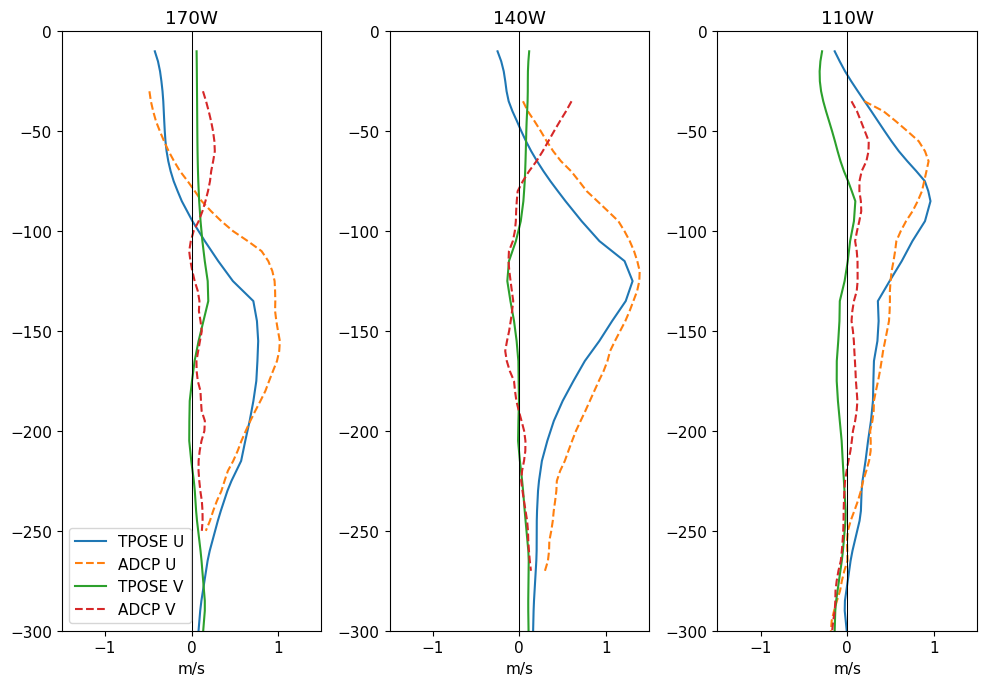

In [35]:
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0].sortby('time'),start_date, end_date)

plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(10,7),ncols=3)
ax[0].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_Uestim,adcp_by_lon_subset.depth,label='TPOSE U')
ax[0].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_U,adcp_by_lon_subset.depth,label='ADCP U',linestyle='--')
ax[0].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_Vestim,adcp_by_lon_subset.depth,label='TPOSE V')
ax[0].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_V,adcp_by_lon_subset.depth,label='ADCP V',linestyle='--')
# ax[0].plot(uncertainty,adcp_by_lon_subset.depth,label='Data Std Dev',linestyle=':')
ax[0].axvline(0, color='k', linewidth=0.75)
ax[0].set_xlim(-1.5,1.5)
ax[0].set_xlabel('m/s')
ax[0].legend()
ax[0].set_title('170W')
ax[0].set_ylim(-300,0)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0].sortby('time'),start_date, end_date)

ax[1].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_Uestim,adcp_by_lon_subset.depth,label='TPOSE U')
ax[1].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_U,adcp_by_lon_subset.depth,label='ADCP U',linestyle='--')
ax[1].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_Vestim,adcp_by_lon_subset.depth,label='TPOSE V')
ax[1].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_V,adcp_by_lon_subset.depth,label='ADCP V',linestyle='--')
# ax[1].plot(uncertainty,adcp_by_lon_subset.depth,label='Data Std Dev',linestyle=':')
ax[1].axvline(0, color='k', linewidth=0.75)
ax[1].set_xlim(-1.5,1.5)
ax[1].set_xlabel('m/s')
ax[1].set_title('140W')
ax[1].set_ylim(-300,0)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0].sortby('time'),start_date, end_date)

ax[2].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_Uestim,adcp_by_lon_subset.depth,label='TPOSE U')
ax[2].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_U,adcp_by_lon_subset.depth,label='ADCP U',linestyle='--')
ax[2].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_Vestim,adcp_by_lon_subset.depth,label='TPOSE V')
ax[2].plot(adcp_by_lon_subset.isel(iPROF=-1).prof_V,adcp_by_lon_subset.depth,label='ADCP V',linestyle='--')
# ax[2].plot(uncertainty,adcp_by_lon_subset.depth,label='Data Std Dev',linestyle=' :')
ax[2].axvline(0, color='k', linewidth=0.75)
ax[2].set_xlim(-1.5,1.5)
ax[2].set_xlabel('m/s')
ax[2].set_title('110W')
ax[2].set_ylim(-300,0)

plt.tight_layout()

filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_RMSE_timestepN.png'
plt.savefig(filename)

### Velocity Bias Over Time

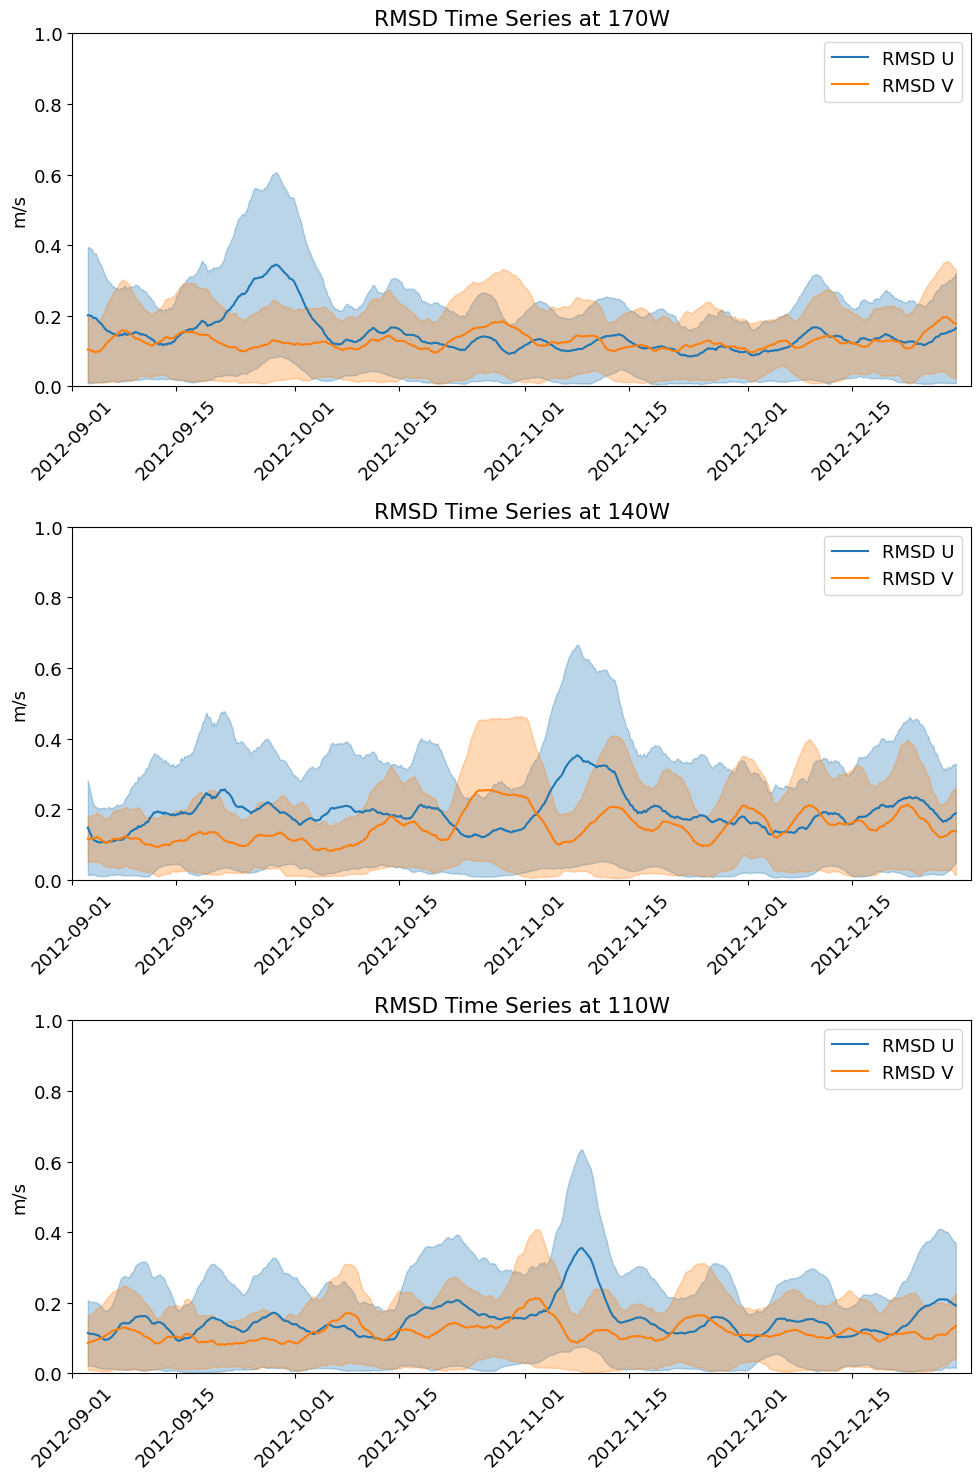

In [36]:
plt.rcParams['font.size'] = 13
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0].sortby('time'),start_date, end_date)

diff_U = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff_V = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

# take rolling mean to smooth time series
rms_diffU = np.sqrt((diff_U**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
rms_diffV = np.sqrt((diff_V**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
std_diffU = diff_U.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()
std_diffV = diff_V.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()

start_string = pd.to_datetime(start_date)
end_string = pd.to_datetime(end_date)

fig, ax = plt.subplots(figsize=(10,15),nrows=3)
ax[0].plot(adcp_by_lon_subset.time, rms_diffU, color='tab:blue', label='RMSD U')
ax[0].plot(adcp_by_lon_subset.time, rms_diffV, color='tab:orange', label='RMSD V')
ax[0].fill_between(adcp_by_lon_subset.time, rms_diffU-std_diffU, rms_diffU+std_diffU, color='tab:blue', alpha=0.3, label='_nolabel_')
ax[0].fill_between(adcp_by_lon_subset.time, rms_diffV-std_diffV, rms_diffV+std_diffV, color='tab:orange', alpha=0.3, label='_nolabel_')
ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_ylabel('m/s')
ax[0].set_title('RMSD Time Series at 170W')
ax[0].legend()
ax[0].set_ylim(0,1.0)
ax[0].set_xlim(start_string, end_string)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0].sortby('time'),start_date, end_date)

diff_U = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff_V = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

# take rolling mean to smooth time series
rms_diffU = np.sqrt((diff_U**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
rms_diffV = np.sqrt((diff_V**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
std_diffU = diff_U.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()
std_diffV = diff_V.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()

ax[1].plot(adcp_by_lon_subset.time, rms_diffU, color='tab:blue', label='RMSD U')
ax[1].plot(adcp_by_lon_subset.time, rms_diffV, color='tab:orange', label='RMSD V')
ax[1].fill_between(adcp_by_lon_subset.time, rms_diffU-std_diffU, rms_diffU+std_diffU, color='tab:blue', alpha=0.3, label='_nolabel_')
ax[1].fill_between(adcp_by_lon_subset.time, rms_diffV-std_diffV, rms_diffV+std_diffV, color='tab:orange', alpha=0.3, label='_nolabel_')
ax[1].set_xlabel('')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_ylabel('m/s')
ax[1].set_title('RMSD Time Series at 140W')
ax[1].legend()
ax[1].set_ylim(0,1.0)
ax[1].set_xlim(start_string, end_string)

adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0].sortby('time'),start_date, end_date)

diff_U = adcp_by_lon_subset.prof_Uestim - adcp_by_lon_subset.prof_U
diff_V = adcp_by_lon_subset.prof_Vestim - adcp_by_lon_subset.prof_V

# take rolling mean to smooth time series
rms_diffU = np.sqrt((diff_U**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
rms_diffV = np.sqrt((diff_V**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
std_diffU = diff_U.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()
std_diffV = diff_V.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()

ax[2].plot(adcp_by_lon_subset.time, rms_diffU, color='tab:blue', label='RMSD U')
ax[2].plot(adcp_by_lon_subset.time, rms_diffV, color='tab:orange', label='RMSD V')
ax[2].fill_between(adcp_by_lon_subset.time, rms_diffU-std_diffU, rms_diffU+std_diffU, color='tab:blue', alpha=0.3, label='_nolabel_')
ax[2].fill_between(adcp_by_lon_subset.time, rms_diffV-std_diffV, rms_diffV+std_diffV, color='tab:orange', alpha=0.3, label='_nolabel_')
ax[2].set_xlabel('')
ax[2].tick_params(axis='x', rotation=45)
ax[2].set_ylabel('m/s')
ax[2].set_title('RMSD Time Series at 110W')
ax[2].legend()
ax[2].set_ylim(0,1.0)
ax[2].set_xlim(start_string, end_string)

plt.tight_layout()
filename = foldername + 'adcp_UV_vs_Iter' + str(iter) + '_bias_time_series.png'
plt.savefig(filename)


In [37]:
def select_data_by_depth(group, start_depth, end_depth):
    """
    Slice a group (Dataset) by time without overwriting lon.
    
    group: xarray Dataset for a single lon
    start_time: np.datetime64 or string
    """
    # Boolean mask along the profile dimension (iPROF)
    mask = group.depth <= start_depth

    if end_depth is not None:
        mask &= group.depth >= end_depth
    
    # Select the profiles, keep all coordinates intact
    return group.isel(iDEPTH=mask)

### Velocity Spectra

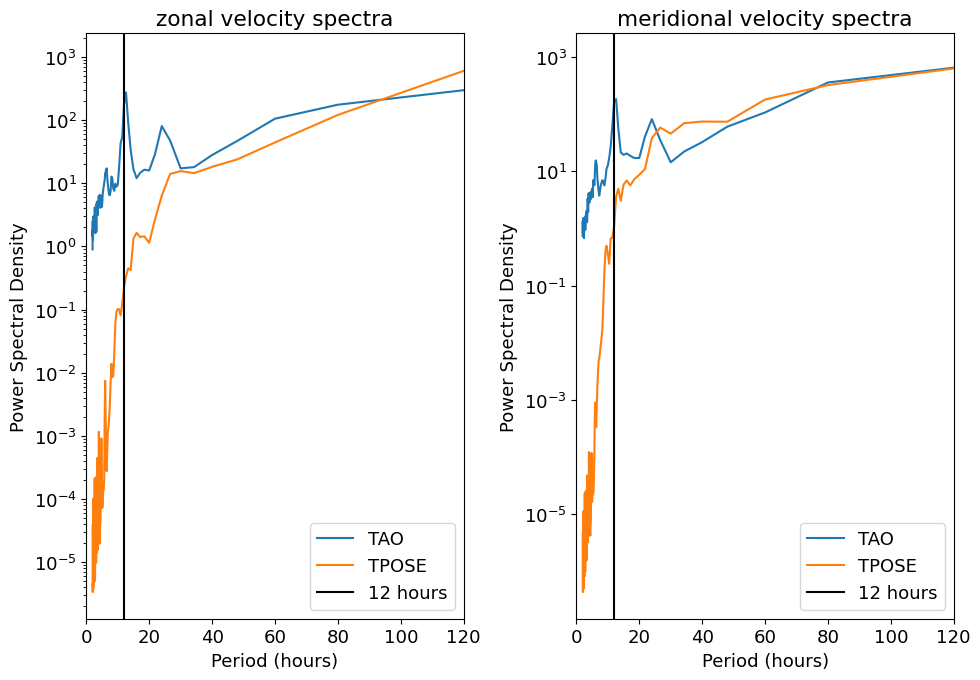

In [38]:
from scipy.signal import welch
fs = 1/(60*60)  # 1 sample per hour

start_date = '2012-09-01'
end_date = '2012-12-31'
depth_upper = 0
depth_lower = -250
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0].sortby('time'), start_date, end_date)

adcp_U_140 = adcp_by_lon_subset.prof_U.dropna(dim='iDEPTH',how='any')
adcp_U_140 = select_data_by_depth(adcp_U_140, depth_upper, depth_lower)
f, Pxx_U_TAO = welch(adcp_U_140.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

adcp_U_140_TPOSE = adcp_by_lon_subset.prof_Uestim.dropna(dim='iPROF',how='any')
adcp_U_140_TPOSE = select_data_by_depth(adcp_U_140_TPOSE, depth_upper, depth_lower)
f, Pxx_U_TPOSE = welch(adcp_U_140_TPOSE.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

fig, ax = plt.subplots(figsize=(10,7), ncols=2)
# spectrum of the timeseries
ax[0].semilogy(1/f/3600, Pxx_U_TAO, label='TAO')
ax[0].semilogy(1/f/3600, Pxx_U_TPOSE, label='TPOSE')
ax[0].axvline(12,label='12 hours',color='k')
ax[0].set_xlim(0,(12*10))
ax[0].legend()
ax[0].set_title('zonal velocity spectra')
ax[0].set_xlabel('Period (hours)')
ax[0].set_ylabel('Power Spectral Density')

adcp_V_140 = adcp_by_lon_subset.prof_V.dropna(dim='iDEPTH',how='any')
adcp_V_140 = select_data_by_depth(adcp_V_140, depth_upper, depth_lower)
f, Pxx_V_TAO = welch(adcp_V_140.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')
adcp_V_140 = adcp_by_lon_subset.prof_Vestim.dropna(dim='iPROF',how='any')
adcp_V_140 = select_data_by_depth(adcp_V_140, depth_upper, depth_lower)
f, Pxx_V_TPOSE = welch(adcp_V_140.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

ax[1].semilogy(1/f/3600, Pxx_V_TAO, label='TAO')
ax[1].semilogy(1/f/3600, Pxx_V_TPOSE, label='TPOSE')
ax[1].axvline(12,label='12 hours',color='k')
ax[1].set_xlim(0,(12*10))
ax[1].legend()
ax[1].set_title('meridional velocity spectra')
ax[1].set_xlabel('Period (hours)')
ax[1].set_ylabel('Power Spectral Density')
plt.tight_layout()
fig.savefig(foldername + 'adcp_UV_vs_Iter' + str(iter) + '_spectra_140W_high_freq.png')

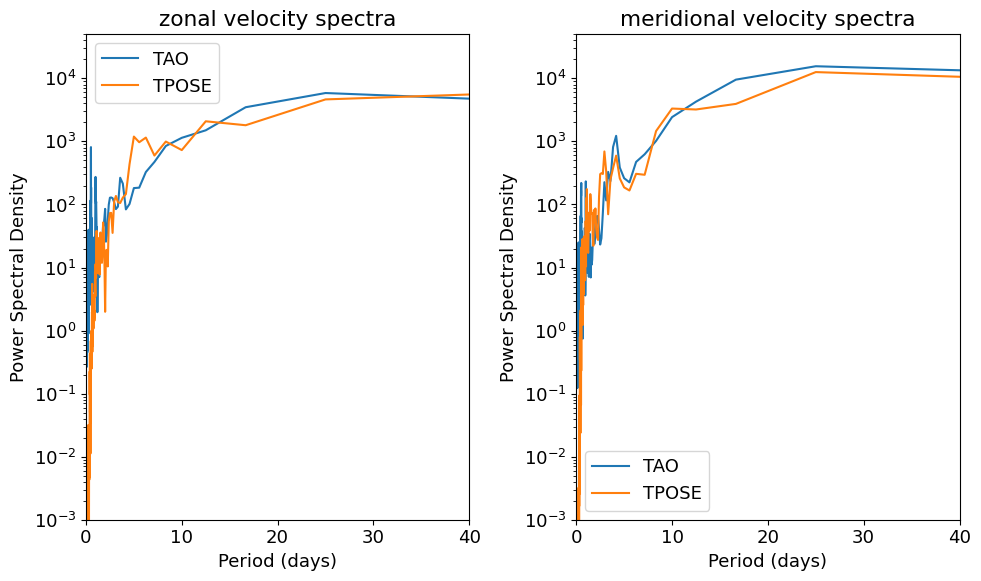

In [39]:
fs = 1/(60*60)  # 1 sample per hour

depth_upper = 0
depth_lower = -250
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-140.0].sortby('time'), start_date, end_date)

adcp_U_140 = adcp_by_lon_subset.prof_U.dropna(dim='iDEPTH',how='any')
adcp_U_140 = select_data_by_depth(adcp_U_140, depth_upper, depth_lower)
f, Pxx_U_TAO = welch(adcp_U_140.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

adcp_U_140_TPOSE = adcp_by_lon_subset.prof_Uestim.dropna(dim='iPROF',how='any')
adcp_U_140_TPOSE = select_data_by_depth(adcp_U_140_TPOSE, depth_upper, depth_lower)
f, Pxx_U_TPOSE = welch(adcp_U_140_TPOSE.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

fig, ax = plt.subplots(figsize=(10,6), ncols=2)
# spectrum of the timeseries
ax[0].semilogy(1/f/86400, Pxx_U_TAO, label='TAO')
ax[0].semilogy(1/f/86400, Pxx_U_TPOSE, label='TPOSE')
# ax[0].axvline(12,label='12 hours',color='k')
ax[0].set_xlim(0,40)
ax[0].set_ylim(1e-3,5e4)
ax[0].legend()
ax[0].set_title('zonal velocity spectra')
ax[0].set_xlabel('Period (days)')
ax[0].set_ylabel('Power Spectral Density')

adcp_V_140 = adcp_by_lon_subset.prof_V.dropna(dim='iDEPTH',how='any')
adcp_V_140 = select_data_by_depth(adcp_V_140, depth_upper, depth_lower)
f, Pxx_V_TAO = welch(adcp_V_140.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')
adcp_V_140 = adcp_by_lon_subset.prof_Vestim.dropna(dim='iPROF',how='any')
adcp_V_140 = select_data_by_depth(adcp_V_140, depth_upper, depth_lower)
f, Pxx_V_TPOSE = welch(adcp_V_140.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

ax[1].semilogy(1/f/86400, Pxx_V_TAO, label='TAO')
ax[1].semilogy(1/f/86400, Pxx_V_TPOSE, label='TPOSE')
# ax[1].axvline(12,label='12 hours',color='k')
ax[1].set_xlim(0,40)
ax[1].set_ylim(1e-3,5e4)
ax[1].legend()
ax[1].set_title('meridional velocity spectra')
ax[1].set_xlabel('Period (days)')
ax[1].set_ylabel('Power Spectral Density')
plt.tight_layout()
fig.savefig(foldername + 'adcp_UV_vs_Iter' + str(iter) + '_spectra_140W.png')

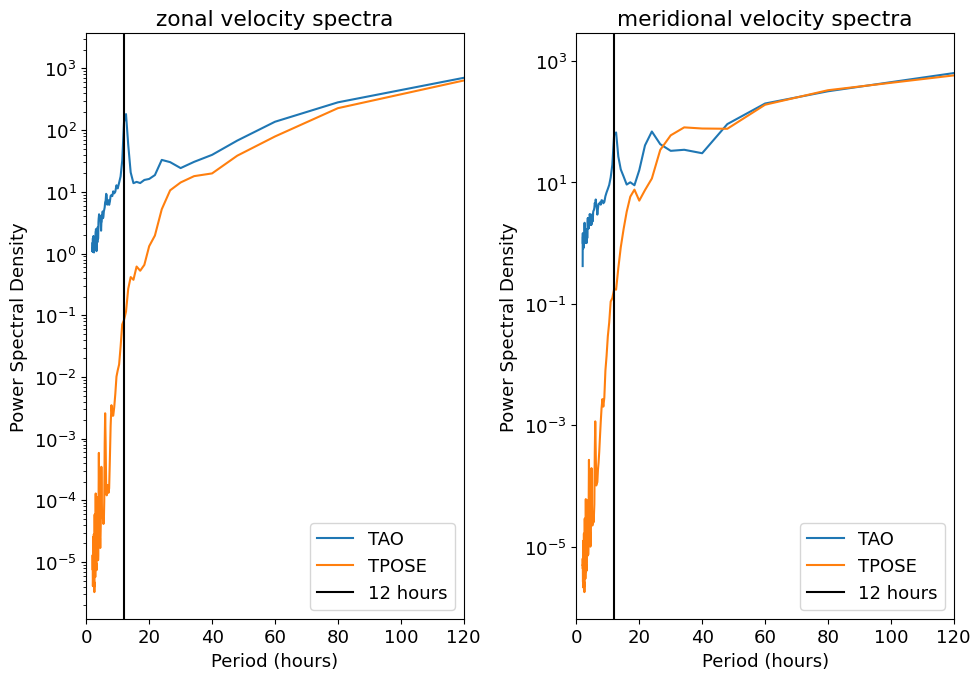

In [40]:
fs = 1/(60*60)  # 1 sample per hour

start_date = '2012-09-01'
end_date = '2012-12-31'
depth_upper = 0
depth_lower = -200
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0].sortby('time'), start_date, end_date)

adcp_U_110 = adcp_by_lon_subset.prof_U.dropna(dim='iDEPTH',how='any')
adcp_U_110 = select_data_by_depth(adcp_U_110, depth_upper, depth_lower)
f, Pxx_U_TAO = welch(adcp_U_110.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

adcp_U_110_TPOSE = adcp_by_lon_subset.prof_Uestim.dropna(dim='iPROF',how='any')
adcp_U_110_TPOSE = select_data_by_depth(adcp_U_110_TPOSE, depth_upper, depth_lower)
f, Pxx_U_TPOSE = welch(adcp_U_110_TPOSE.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

fig, ax = plt.subplots(figsize=(10,7), ncols=2)

# spectrum of the timeseries
ax[0].semilogy(1/f/3600, Pxx_U_TAO, label='TAO')
ax[0].semilogy(1/f/3600, Pxx_U_TPOSE, label='TPOSE')
ax[0].set_xlim(0,(12*10))
ax[0].axvline(12,label='12 hours',color='k')
ax[0].legend()
ax[0].set_title('zonal velocity spectra')
ax[0].set_xlabel('Period (hours)')
ax[0].set_ylabel('Power Spectral Density')

adcp_V_110 = adcp_by_lon_subset.prof_V.dropna(dim='iDEPTH',how='any')
adcp_V_110 = select_data_by_depth(adcp_V_110, depth_upper, depth_lower)
f, Pxx_V_TAO = welch(adcp_V_110.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')
adcp_V_110 = adcp_by_lon_subset.prof_Vestim.dropna(dim='iPROF',how='any')
adcp_V_110 = select_data_by_depth(adcp_V_110, depth_upper, depth_lower)
f, Pxx_V_TPOSE = welch(adcp_V_110.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

ax[1].semilogy(1/f/3600, Pxx_V_TAO, label='TAO')
ax[1].semilogy(1/f/3600, Pxx_V_TPOSE, label='TPOSE')
ax[1].axvline(12,label='12 hours',color='k')
ax[1].set_xlim(0,(12*10))
ax[1].legend()
ax[1].set_title('meridional velocity spectra')
ax[1].set_xlabel('Period (hours)')
ax[1].set_ylabel('Power Spectral Density')
plt.tight_layout()
fig.savefig(foldername + 'adcp_UV_vs_Iter' + str(iter) + '_spectra_110W_high_freq.png')

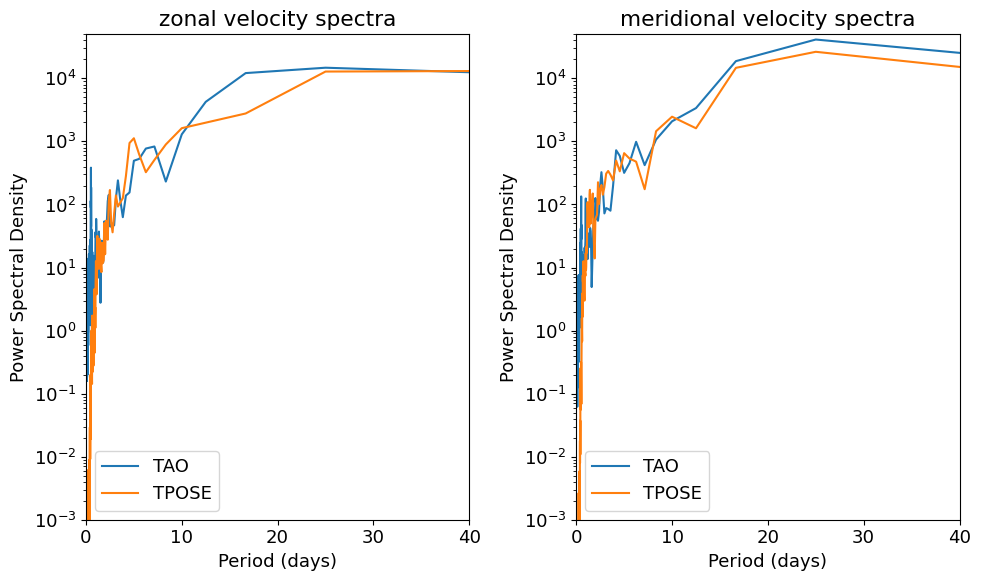

In [41]:
fs = 1/(60*60)  # 1 sample per hour

depth_upper = 0
depth_lower = -250
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-110.0].sortby('time'), start_date, end_date)

adcp_U_110 = adcp_by_lon_subset.prof_U.dropna(dim='iDEPTH',how='any')
adcp_U_110 = select_data_by_depth(adcp_U_110, depth_upper, depth_lower)
f, Pxx_U_TAO = welch(adcp_U_110.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

adcp_U_110_TPOSE = adcp_by_lon_subset.prof_Uestim.dropna(dim='iPROF',how='any')
adcp_U_110_TPOSE = select_data_by_depth(adcp_U_110_TPOSE, depth_upper, depth_lower)
f, Pxx_U_TPOSE = welch(adcp_U_110_TPOSE.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

fig, ax = plt.subplots(figsize=(10,6), ncols=2)
# spectrum of the timeseries
ax[0].semilogy(1/f/86400, Pxx_U_TAO, label='TAO')
ax[0].semilogy(1/f/86400, Pxx_U_TPOSE, label='TPOSE')
# ax[0].axvline(12,label='12 hours',color='k')
ax[0].set_xlim(0,40)
ax[0].set_ylim(1e-3,5e4)
ax[0].legend()
ax[0].set_title('zonal velocity spectra')
ax[0].set_xlabel('Period (days)')
ax[0].set_ylabel('Power Spectral Density')

adcp_V_110 = adcp_by_lon_subset.prof_V.dropna(dim='iDEPTH',how='any')
adcp_V_110 = select_data_by_depth(adcp_V_110, depth_upper, depth_lower)
f, Pxx_V_TAO = welch(adcp_V_110.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')
adcp_V_110 = adcp_by_lon_subset.prof_Vestim.dropna(dim='iPROF',how='any')
adcp_V_110 = select_data_by_depth(adcp_V_110, depth_upper, depth_lower)
f, Pxx_V_TPOSE = welch(adcp_V_110.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

ax[1].semilogy(1/f/86400, Pxx_V_TAO, label='TAO')
ax[1].semilogy(1/f/86400, Pxx_V_TPOSE, label='TPOSE')
# ax[1].axvline(12,label='12 hours',color='k')
ax[1].set_xlim(0,40)
ax[1].set_ylim(1e-3,5e4)
ax[1].legend()
ax[1].set_title('meridional velocity spectra')
ax[1].set_xlabel('Period (days)')
ax[1].set_ylabel('Power Spectral Density')
plt.tight_layout()
fig.savefig(foldername + 'adcp_UV_vs_Iter' + str(iter) + '_spectra_110W.png')

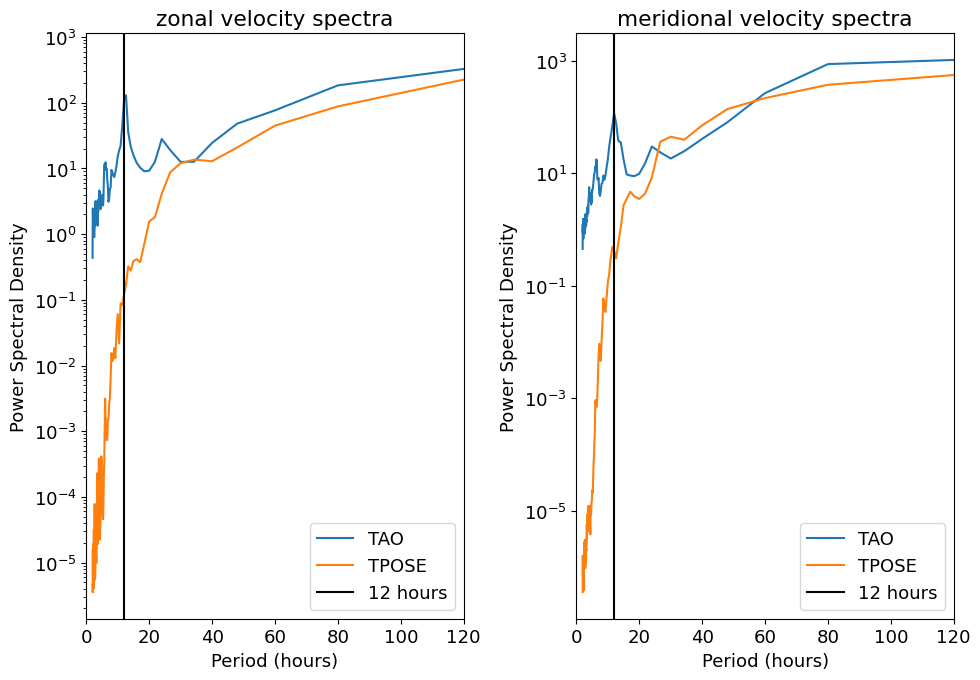

In [42]:
fs = 1/(60*60)  # 1 sample per hour

depth_upper = 0
depth_lower = -250
start_date = '2012-09-01'
end_date = '2012-12-31'
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0].sortby('time'), start_date, end_date)

adcp_U_170 = adcp_by_lon_subset.prof_U.dropna(dim='iDEPTH',how='any')
adcp_U_170 = select_data_by_depth(adcp_U_170, depth_upper, depth_lower)
f, Pxx_U_TAO = welch(adcp_U_170.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

adcp_U_170_TPOSE = adcp_by_lon_subset.prof_Uestim.dropna(dim='iPROF',how='any')
adcp_U_170_TPOSE = select_data_by_depth(adcp_U_170_TPOSE, depth_upper, depth_lower)
f, Pxx_U_TPOSE = welch(adcp_U_170_TPOSE.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

fig, ax = plt.subplots(figsize=(10,7), ncols=2)

# spectrum of the timeseries
ax[0].semilogy(1/f/3600, Pxx_U_TAO, label='TAO')
ax[0].semilogy(1/f/3600, Pxx_U_TPOSE, label='TPOSE')
ax[0].axvline(12,label='12 hours',color='k')
ax[0].set_xlim(0,(12*10))
ax[0].legend()
ax[0].set_title('zonal velocity spectra')
ax[0].set_xlabel('Period (hours)')
ax[0].set_ylabel('Power Spectral Density')

adcp_V_170 = adcp_by_lon_subset.prof_V.dropna(dim='iDEPTH',how='any')
adcp_V_170 = select_data_by_depth(adcp_V_170, depth_upper, depth_lower)
f, Pxx_V_TAO = welch(adcp_V_170.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')
adcp_V_170 = adcp_by_lon_subset.prof_Vestim.dropna(dim='iPROF',how='any')
adcp_V_170 = select_data_by_depth(adcp_V_170, depth_upper, depth_lower)
f, Pxx_V_TPOSE = welch(adcp_V_170.mean(dim='iDEPTH'), fs=fs, nperseg=(24*10), detrend='linear')

ax[1].semilogy(1/f/3600, Pxx_V_TAO, label='TAO')
ax[1].semilogy(1/f/3600, Pxx_V_TPOSE, label='TPOSE')
ax[1].axvline(12,label='12 hours',color='k')
ax[1].set_xlim(0,(12*10))
ax[1].legend()
ax[1].set_title('meridional velocity spectra')
ax[1].set_xlabel('Period (hours)')
ax[1].set_ylabel('Power Spectral Density')

plt.tight_layout()
fig.savefig(foldername + 'adcp_UV_vs_Iter' + str(iter) + '_spectra_170W_high_freq.png')

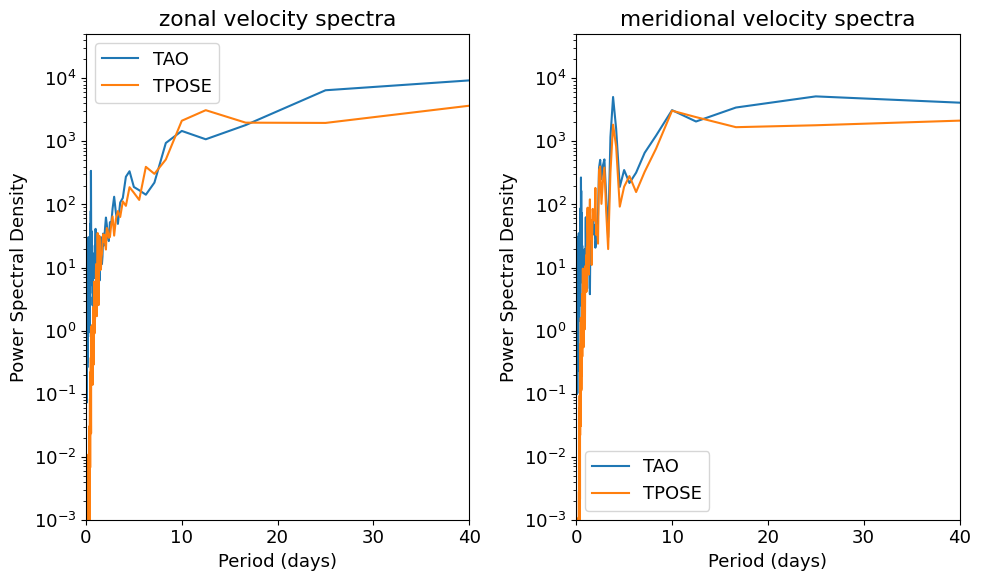

In [43]:
fs = 1/(60*60)  # 1 sample per hour

depth_upper = 0
depth_lower = -250
adcp_by_lon_subset = slice_by_time_keep_lon(adcp_by_lon[-170.0].sortby('time'), start_date, end_date)

adcp_U_170 = adcp_by_lon_subset.prof_U.dropna(dim='iDEPTH',how='any')
adcp_U_170 = select_data_by_depth(adcp_U_170, depth_upper, depth_lower)
f, Pxx_U_TAO = welch(adcp_U_170.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

adcp_U_170_TPOSE = adcp_by_lon_subset.prof_Uestim.dropna(dim='iPROF',how='any')
adcp_U_170_TPOSE = select_data_by_depth(adcp_U_170_TPOSE, depth_upper, depth_lower)
f, Pxx_U_TPOSE = welch(adcp_U_170_TPOSE.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

fig, ax = plt.subplots(figsize=(10,6), ncols=2)
# spectrum of the timeseries
ax[0].semilogy(1/f/86400, Pxx_U_TAO, label='TAO')
ax[0].semilogy(1/f/86400, Pxx_U_TPOSE, label='TPOSE')
# ax[0].axvline(12,label='12 hours',color='k')
ax[0].set_xlim(0,40)
ax[0].set_ylim(1e-3,5e4)
ax[0].legend()
ax[0].set_title('zonal velocity spectra')
ax[0].set_xlabel('Period (days)')
ax[0].set_ylabel('Power Spectral Density')

adcp_V_170 = adcp_by_lon_subset.prof_V.dropna(dim='iDEPTH',how='any')
adcp_V_170 = select_data_by_depth(adcp_V_170, depth_upper, depth_lower)
f, Pxx_V_TAO = welch(adcp_V_170.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')
adcp_V_170 = adcp_by_lon_subset.prof_Vestim.dropna(dim='iPROF',how='any')
adcp_V_170 = select_data_by_depth(adcp_V_170, depth_upper, depth_lower)
f, Pxx_V_TPOSE = welch(adcp_V_170.mean(dim='iDEPTH'), fs=fs, nperseg=(24*50), detrend='linear')

ax[1].semilogy(1/f/86400, Pxx_V_TAO, label='TAO')
ax[1].semilogy(1/f/86400, Pxx_V_TPOSE, label='TPOSE')
# ax[1].axvline(12,label='12 hours',color='k')
ax[1].set_xlim(0,40)
ax[1].set_ylim(1e-3,5e4)
ax[1].legend()
ax[1].set_title('meridional velocity spectra')
ax[1].set_xlabel('Period (days)')
ax[1].set_ylabel('Power Spectral Density')
plt.tight_layout()
fig.savefig(foldername + 'adcp_UV_vs_Iter' + str(iter) + '_spectra_170W.png')

In [ ]:
# client.shutdown()
# cluster.close()
# client.close()